In [1]:
from figures_functions import *

## Functions

#### Land-sea mask

In [2]:
maskls=xr.open_mfdataset('~/cmip6stop/land_sea_masks/landsea.nc')
maskl=maskls.LSMASK.where(maskls.LSMASK==1)

#### Calculation of areas

In [24]:
tit=['glob','trop','mid','high']
CS=xr.open_dataset('~/ResultsCS/CS_nee_Fluxcom.nc'); CS=CS.FLUXCOM


Azones=np.zeros(len(tit)) # Area in each spatial divion [m2].

#for k in range(3):
for k in range(len(tit)):#len(titles) # spatial divisions.
    if k==0:CSz=CS # Global
    if k==1:mask=((CS.lat <= 22.5)&(CS.lat >= -22.5)) # Tropics
    if k==2:
        mask1=(CS.lat > 22.5)&(CS.lat < 55.0) # mid latitudes.
        mask2=(CS.lat < -22.5) # mid latitudes.
    if k==3:mask=(CS.lat >= 55.0) # high latitudes
    if k!=0:CSz=CS.where(mask,drop=True)
    if k==2:
        CSz1=CS.where(mask1,drop=True);CSz2=CS.where(mask2,drop=True)
        Azones[k]=grid_cell_areas2(CSz1)+grid_cell_areas2(CSz2) 
    else:
        Azones[k]=grid_cell_areas2(CSz)

## FLUXCOM-X

In [31]:
MT=xr.open_dataset('~/ResultsCS/MT_nee_Fluxcom.nc')
landarea=grid_cell_areas2(MT) # in m2.
MT=MT.FLUXCOM
MT["time"]=MT["time"].astype("datetime64[ns]")
CS=xr.open_dataset('~/ResultsCS/CS_nee_Fluxcom.nc')
CS=CS.FLUXCOM/1e4 # to ha
mod='FLUXCOM-X'
mod2='Fluxcom'

var='NEE'


### Fig 1. Map and latitudinal variation

#### Accumulation along latitudes

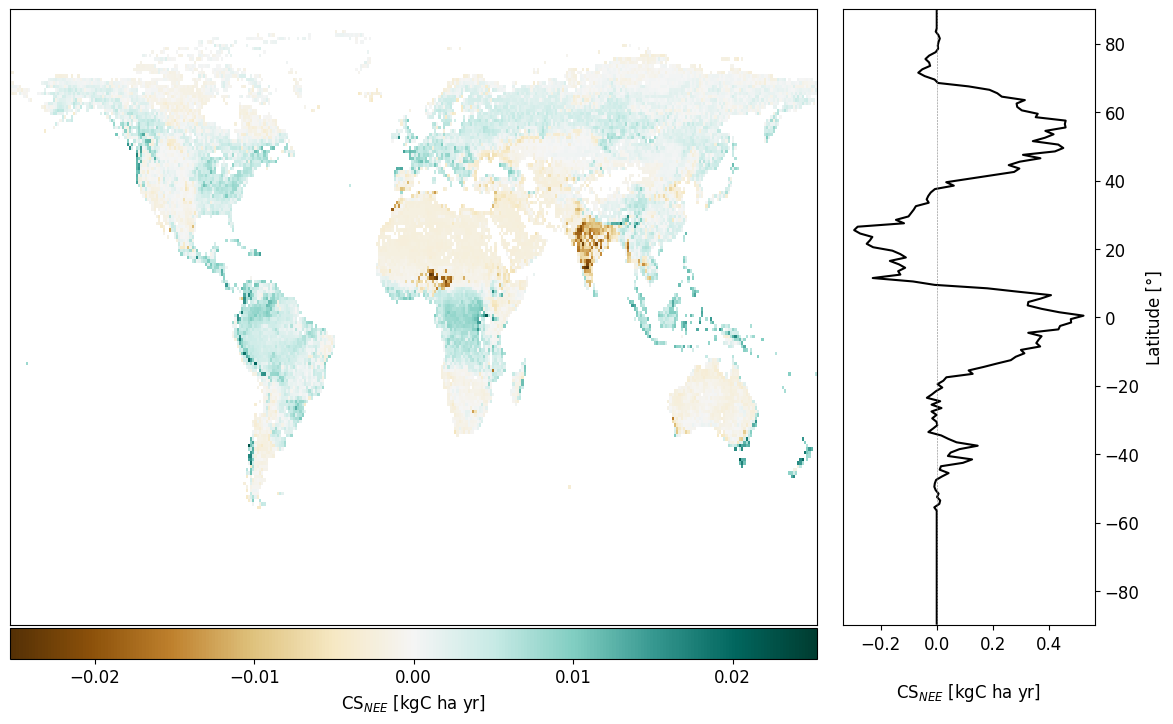

In [32]:
# Note that this is not corrected by area.
CS_x=CS.sum(["lon"])
CS_lat=CS_x.to_dataset(name=mod)

plt.rcParams.update({'font.size':12})
fig3=plt.figure(figsize=(14,8))
grid=plt.GridSpec(2,4,wspace=0.1,hspace=0.2)
ax1=plt.subplot(grid[0:2,0:3])
ax2=plt.subplot(grid[0:2,3:])#,xticklabels=[])#,sharey=ax1)

CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=CS.plot(xticks=[],yticks=[],cmap=plt.cm.BrBG,add_colorbar=False,ax=ax1)
ax1.set_xlabel(''); ax1.set_ylabel('')
ax1.set_title('')
ax1.set_ylim(-90,90)

cmap=plt.cm.coolwarm
colors=cmap(np.linspace(0,1,1))

gc.collect()   
CS.sum(["lon"]).plot(ax=ax2,y='lat',color='black')


ax2.yaxis.tick_right() 
ax2.set_ylabel('Latitude [°]')
ax2.yaxis.set_label_position("right")
ax2.set_xlabel(r"CS$_{NEE}$ [kgC ha yr]",labelpad=20)
ax2.axvline(x=0,color='gray',ls='--',linewidth=0.4)
ax2.set_title('')
ax2.set_ylim(-90,90)
#ax2.ticklabel_format(axis='x',style='sci',scilimits=(5,5))

axins=inset_axes(ax1,width="100%",height="5%",loc='lower center',borderpad=-2)
fig3.colorbar(csp,cax=axins,orientation="horizontal",label=r'CS$_{NEE}$ [kgC ha yr]')

fig3.savefig('/home/_ehoyos/cmip6stop/CS/Figures/'+mod+'_CS_map_latitude.pdf')

#### Average along latitudes

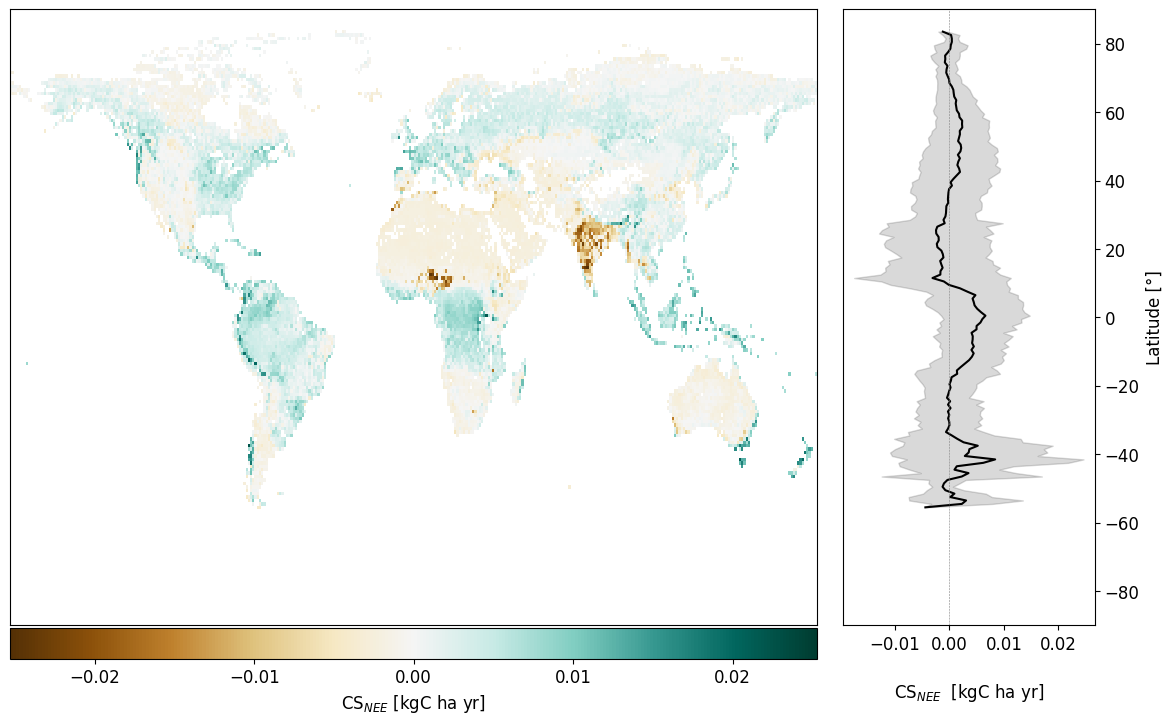

In [33]:
CS_x=CS.sum(["lon"])
CS_lat=CS_x.to_dataset(name=mod)

plt.rcParams.update({'font.size':12})
fig3=plt.figure(figsize=(14,8))
grid=plt.GridSpec(2,4,wspace=0.1,hspace=0.2)
ax1=plt.subplot(grid[0:2,0:3])
ax2=plt.subplot(grid[0:2,3:])#,xticklabels=[])#,sharey=ax1)

CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=CS.plot(xticks=[],yticks=[],cmap=plt.cm.BrBG,add_colorbar=False,ax=ax1)
ax1.set_xlabel(''); ax1.set_ylabel('')
ax1.set_title('')
ax1.set_ylim(-90,90)

CS.mean(["lon"]).plot(ax=ax2,y='lat',color='black')
ax2.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax2.yaxis.tick_right() 
ax2.set_ylabel('Latitude [°]')
ax2.yaxis.set_label_position("right")
ax2.set_xlabel(r"CS$_{NEE}$  [kgC ha yr]",labelpad=20)
ax2.axvline(x=0,color='gray',ls='--',linewidth=0.4)
ax2.set_title('')
ax2.set_ylim(-90,90)

axins=inset_axes(ax1,width="100%",height="5%",loc='lower center',borderpad=-2)
fig3.colorbar(csp,cax=axins,orientation="horizontal",label=r'CS$_{NEE}$ [kgC ha yr]')

fig3.savefig('/home/_ehoyos/cmip6stop/CS/Figures/'+mod+'_CS_map_latitude_mean.pdf')

### Fig 2. Temporal variations of CS 

#### Save info in .csv

In [34]:
Mt=MT
tit=['glob','trop','mid','high']
for k in range(len(tit)):#len(titles) # spatial divisions.
    if k==0:Mts=Mt # Global
    if k==1:mask=((Mt.lat <= 22.5)&(Mt.lat >= -22.5)) # Tropics
    if k==2:
        mask1=(Mt.lat > 22.5)&(Mt.lat < 55.0) # mid latitudes.
        mask2=(Mt.lat < -22.5) # mid latitudes.
    if k==3:mask=(Mt.lat >= 55.0) # high latitudes
        
    if k!=0: Mts=Mt.where(mask,drop=True)
    #Mts_xy=calc_spatial_total(Mts) #Mts.sum("lon").sum("lat")
    
# Time series  
    if k==2:
        Mts=Mt
        css_cum=Mts.cumulative_integrate("time",datetime_unit='D')/30.4/12 
        cssz1=css_cum.where(mask1,drop=True);cssz2=css_cum.where(mask2,drop=True)
        css_cumxy=calc_spatial_integral(cssz1)+calc_spatial_integral(cssz2) 
    else:
        css_cum=Mts.cumulative_integrate("time",datetime_unit='D')/30.4/12 
        css_cumxy=calc_spatial_integral(css_cum)#css_cum.sum(["lon"]).sum(["lat"])
    if k==0:CSl=css_cumxy.to_dataset(name=tit[0])   
    else:CSl[tit[k]]=css_cumxy
           
dfCS=CSl.to_dataframe()
dfCS.to_csv('~/ResultsCS/Lat/cs_cum_lat_Fluxcom.csv')

#### Accumulation at the end of the time series

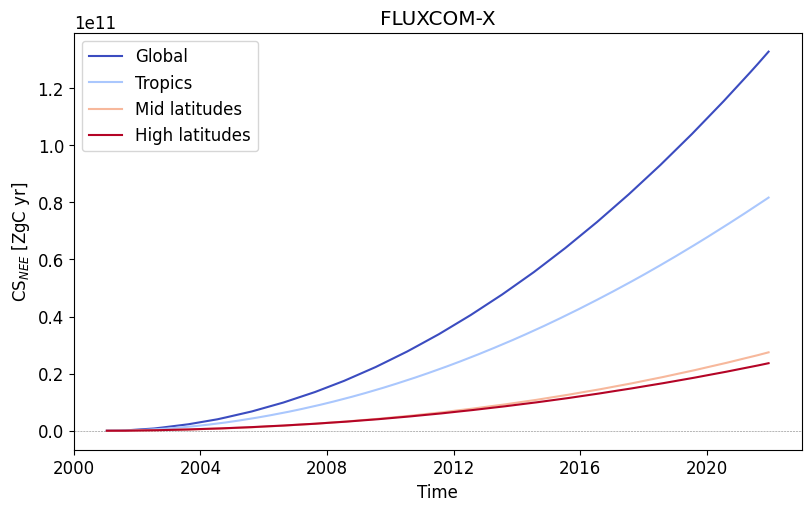

In [35]:
tit=['glob','trop','mid','high']

cmap=plt.cm.coolwarm
colors=cmap(np.linspace(0,1,4))

fig4,ax=plt.subplots(ncols=1,figsize=[8,5],constrained_layout=True)
titles=['Global','Tropics','Mid latitudes','High latitudes']
CSz=pd.read_csv('~/ResultsCS/Lat/cs_cum_lat_'+mod2+'.csv')
CSz["time"]=CSz["time"].apply(pd.to_datetime)
ax.axhline(y=0,color='gray',ls='--',linewidth=0.4)

for k in range(len(titles)): ax.plot(CSz[CSz.columns[0]],CSz[CSz.columns[k+1]]/1e+4,color=colors[k],label=titles[k])
ax.set_xlabel("Time")
ax.set_ylabel("CS$_{NEE}$ [ZgC yr]")
ax.set_title(mod)
ax.legend()

fig4.savefig('/home/_ehoyos/cmip6stop/CS/Figures/'+mod+'_CS_time_final.pdf',bbox_inches="tight")   

## Scatter plots

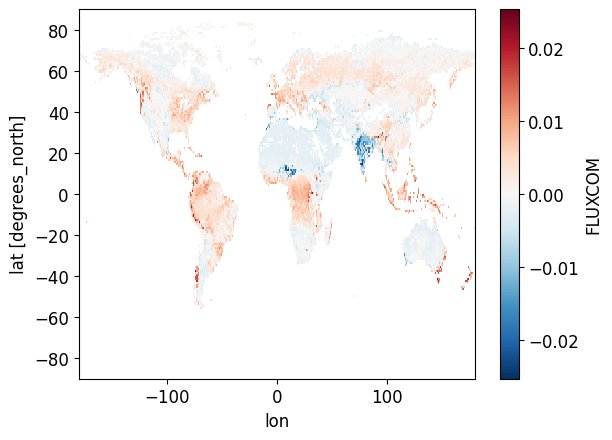

In [46]:
CS.plot()

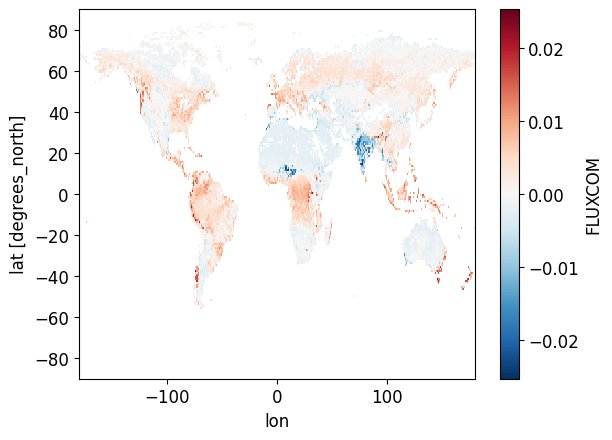

In [53]:
CS.plot()

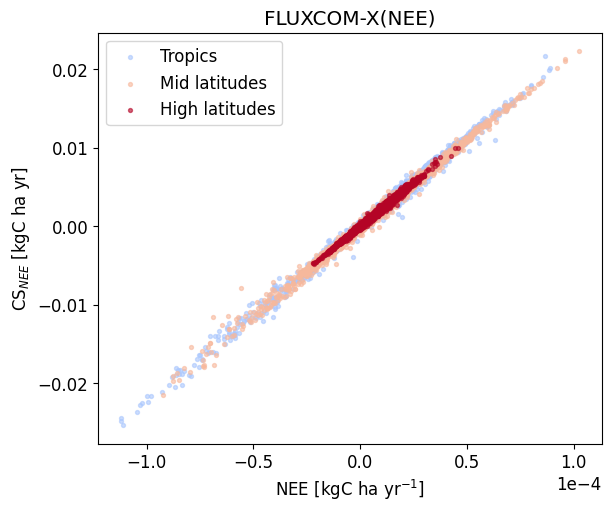

In [57]:
titles=['Global','Tropics','Mid latitudes','High latitudes']
cmap=plt.cm.coolwarm
colors=cmap(np.linspace(0,1,4))


fig,ax=plt.subplots(ncols=1,figsize=[6,5],constrained_layout=True)
xx=xr.open_dataset('~/ResultsCS/nee_mean_'+mod2+'.nc')
xx=xx[list(xx.keys())[0]]
CS2=MT.integrate("time",datetime_unit='D')/30.4/12
CS2=CS2/1e4
xx=xx/1e4
for k in range(1,len(titles)):
    #if k==0:Mts=Mt[lv_Mt[j]] # Global
    if k==1:mask=((xx.lat<=22.5)&(xx.lat>=-22.5)) # Tropics
    if k==2:mask=((xx.lat>22.5)&(xx.lat<55)|(xx.lat<-22.5)) # mid latitudes.
    if k==3:mask=(xx.lat>=55.0) # high latitudes

    ax.scatter(xx[mask],CS2[mask],color=colors[k],s=8,alpha=0.6,label=titles[k])
ax.set_xlabel('NEE [kgC ha yr$^{-1}$]')
ax.set_ylabel(r'CS$_{NEE}$ [kgC ha yr]')
ax.set_title(mod+'(NEE)')
ax.ticklabel_format(axis='x', style='sci', scilimits=(-4,4))
ax.legend()

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/'+mod+'_Scatter_plots.pdf',bbox_inches="tight")   


### Maps

In [23]:
xxv

<xarray.DataArray 'FLUXCOM' (lat: 180, lon: 360)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5

In [64]:
varx=['nee','CSnee']
varX=['NEE','CS$_{NEE}$']
col=["RdYlGn","BrBG"]


with PdfPages('/home/_ehoyos/cmip6stop/CS/Figures/'+mod+'_figures.pdf') as pdf:        
# Map variables.
    plt.rcParams.update({'font.size':7})
    fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[10,12],subplot_kw={"projection": ccrs.Robinson()})
    fig.suptitle('FLUXCOM')     
    a=-1
    for j in range(len(varx)):
        if j<1:
            xx=xr.open_dataset('~/ResultsCS/'+varx[j]+'_mean_'+mod2+'.nc')
            xx=xx/1e+4
        if j==1:xx=CS
        
        if j/2==int(j/2):a=a+1
        if j!=1:xxv=xx[list(xx.keys())[0]]
        else:xxv=xx

        pt=ax[a,j-2*a].contourf(xxv.lon,xxv.lat,xxv,transform=ccrs.PlateCarree(),cmap=col[j])
        ax[a,j-2*a].coastlines()
        if j<1: cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[a,j-2*a],
                                  label=varX[j]+r' [kgC ha yr$^{-1}$]',pad=0.04,aspect=30)
        if j==1: cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[a,j-2*a],
                                  label=varX[j]+r' [kgC ha yr]',pad=0.04,aspect=30)
        cbar.formatter.set_powerlimits((0, 0))
        for c in pt.collections:c.set_edgecolor("face")
    pdf.savefig()
    plt.close()        
        
# # Carbon sequestration with NEP
 
    vv='nee';VV='NEE'
            
    xx=CS
    xxv=xx

    plt.rcParams.update({'font.size':12})
    fig=plt.figure(figsize=(14,10))
    fig.suptitle('FLUXCOM-X ('+VV+')')
    grid=plt.GridSpec(2,4,wspace=0.2,hspace=0.2)
    ax1=plt.subplot(grid[0:2,0:3])
    ax2=plt.subplot(grid[0:2,3:])#,xticklabels=[])#,sharey=ax1)
    
    xxv.coords['lon']=(xxv.coords['lon']+180)%360-180
    xxv=xxv.sortby(xxv.lon)
    #xxv=xxv/1e+18/1e+18
    csp=xxv.plot(xticks=[],yticks=[],cmap=plt.cm.BrBG,add_colorbar=False,ax=ax1)
    ax1.set_xlabel(''); ax1.set_ylabel('')
    ax1.set_title('')
    ax1.set_ylim(-90,90)

    cmap=plt.cm.BrBG
    colors=cmap(np.linspace(0.3,0.7,2))
    y1=xxv.mean(["lon"])
    x=np.linspace(-90,90,180)
    ax2.fill_betweenx(x,y1,where=y1>0,interpolate=True,color=colors[1])
    ax2.fill_betweenx(x,y1,where=y1<0,interpolate=True,color=colors[0])

    xxv.mean(["lon"]).plot(ax=ax2,y='lat',color='black')
    ax2.yaxis.tick_right() 
    ax2.set_ylabel('Latitude [°]')
    ax2.yaxis.set_label_position("right")
    ax2.set_xlabel("CS$_{"+VV+"}$ [kgC ha yr]",labelpad=20)
    ax2.axvline(x=0,color='gray',ls='--')
    ax2.set_title('')
    ax2.set_ylim(-90,90)

    axins=inset_axes(ax1,width="100%",height="5%",loc='lower center',borderpad=-3)
    fig.colorbar(csp,cax=axins,orientation="horizontal",label="CS$_{"+VV+"}$ [kgC ha yr]")
    for c in pt.collections:c.set_edgecolor("face")
    pdf.savefig()
    plt.close()

/tmp/ipykernel_26134/1811085835.py:29: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in pt.collections:c.set_edgecolor("face")
/tmp/ipykernel_26134/1811085835.py:29: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in pt.collections:c.set_edgecolor("face")
/tmp/ipykernel_26134/1811085835.py:73: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in pt.collections:c.set_edgecolor("face")
